# Notebook 9 (V4.3) — $\varphi_{US,t}$ Decay Across $a_{US}$

This notebook compares how fast the U.S. production-labour share $\varphi_{US,t}$ falls as U.S. R&D productivity $a_{US}$ changes in the two-country production economy.

The sweep uses the all-$u$ equilibrium path stored in `result.u_path[t].φ_US`. High `a_US` can push the nonlinear system toward the `φ_floor`, so every row reports residual and validity diagnostics alongside the decay measures.


In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryProductionOLG.jl")

using Printf, Statistics, Plots, LaTeXStrings, Markdown
using Plots.PlotMeasures
gr()

default(size=(940, 560), framestyle=:box, grid=:y, legend=:best,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=10mm, right_margin=7mm, top_margin=7mm, bottom_margin=8mm)


  Activating 

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


## 0. Helpers

The main fitted statistic is the slope in

$$\log \varphi_{US,t}=c-bt+\varepsilon_t,$$

reported as `decay_rate_per_period = b`. Larger values mean faster decline. The threshold dates are often more robust when a high-`a_US` run is close to the numerical floor or has a provisional residual.


In [2]:
late_range(T) = max(1, T - 9):T
value_at(x, t) = x[min(t, length(x))]

function pretty(x)
    x === missing && return ""
    x isa Bool && return string(x)
    x isa Integer && return string(x)
    if x isa AbstractFloat
        if !isfinite(x)
            return string(x)
        elseif abs(x) >= 1000 || (abs(x) > 0 && abs(x) < 1e-3)
            return @sprintf("%.3e", x)
        else
            return @sprintf("%.4f", x)
        end
    end
    return string(x)
end

function html_escape(x)
    s = string(x)
    s = replace(s, "&" => "&amp;")
    s = replace(s, "<" => "&lt;")
    s = replace(s, ">" => "&gt;")
    s = replace(s, "_" => "\\_")
    return s
end

function markdown_table(rows, cols; maxrows=length(rows))
    isempty(rows) && return Markdown.parse("_No rows._")
    io = IOBuffer()
    println(io, "| ", join([html_escape(c) for c in cols], " | "), " |")
    println(io, "| ", join(fill("---", length(cols)), " | "), " |")
    for r in rows[1:min(maxrows, length(rows))]
        println(io, "| ", join([html_escape(pretty(get(r, c, missing))) for c in cols], " | "), " |")
    end
    Markdown.parse(String(take!(io)))
end

function fit_decay_slope(φ; start_t::Int=3, end_t::Int=length(φ))
    idx = [t for t in start_t:min(end_t, length(φ)) if isfinite(φ[t]) && φ[t] > 0]
    length(idx) < 3 && return (slope=NaN, intercept=NaN, r2=NaN, n=length(idx))
    x = Float64.(idx)
    y = log.(φ[idx])
    xbar = mean(x); ybar = mean(y)
    sxx = sum(abs2, x .- xbar)
    sxx <= 0 && return (slope=NaN, intercept=NaN, r2=NaN, n=length(idx))
    slope = sum((x .- xbar) .* (y .- ybar)) / sxx
    intercept = ybar - slope*xbar
    yhat = intercept .+ slope .* x
    sst = sum(abs2, y .- ybar)
    sse = sum(abs2, y .- yhat)
    r2 = sst <= 0 ? NaN : 1 - sse/sst
    return (slope=slope, intercept=intercept, r2=r2, n=length(idx))
end

first_leq(x, threshold) = begin
    idx = findfirst(v -> isfinite(v) && v <= threshold, x)
    idx === nothing ? missing : idx
end


first_leq (generic function with 1 method)

In [3]:
function summarize_phi_decay(a_US; a_W=ProductionParams().a_W, T_max::Int=20, verbose::Bool=false)
    p = ProductionParams(T_max=T_max, a_US=a_US, a_W=a_W)
    row = Dict{String, Any}(
        "a_US" => a_US,
        "a_W" => a_W,
        "T_max" => T_max,
        "φ_floor" => p.φ_floor,
        "status" => "pending"
    )

    try
        result = run_production_simulation(p; verbose=verbose)
        T = length(result.u_path)
        φ = [s.φ_US for s in result.u_path]
        N = [s.N_US for s in result.u_path]
        G = [G_N_US(result.params, s.φ_US) for s in result.u_path]
        dq = [s.d_US / s.q_US for s in result.u_path]
        fit = fit_decay_slope(φ; start_t=3, end_t=T)
        half_threshold = 0.5 * φ[1]
        tenth_threshold = 0.1 * φ[1]
        floor_band = 5 * result.params.φ_floor
        last = late_range(T)

        row["status"] = "ok"
        row["result"] = result
        row["φ_path"] = φ
        row["N_path"] = N
        row["G_path"] = G
        row["dq_path"] = dq
        row["branch_converged"] = result.branch_converged
        row["max_u_residual"] = result.max_u_residual
        row["max_bgp_residual"] = result.max_bgp_residual
        row["psi_ok"] = result.diagnostics.psi_ok
        row["psi_min"] = result.diagnostics.psi_min
        row["equity_weights_ok"] = result.diagnostics.equity_weights_ok
        row["equity_weight_min"] = result.diagnostics.equity_weight_min
        row["valid_core"] = result.branch_converged && result.max_u_residual <= 1e-5 &&
                              result.max_bgp_residual <= 1e-5 &&
                              result.diagnostics.psi_ok && result.diagnostics.equity_weights_ok
        row["valid_exploratory"] = result.max_u_residual <= 1e-4 &&
                                     result.diagnostics.psi_ok && result.diagnostics.equity_weights_ok
        row["φ_1"] = φ[1]
        row["φ_10"] = value_at(φ, 10)
        row["φ_20"] = value_at(φ, 20)
        row["φ_final"] = φ[end]
        row["φ_late_mean"] = mean(φ[last])
        row["decay_rate_per_period"] = -fit.slope
        row["decay_r2"] = fit.r2
        row["half_life_t"] = first_leq(φ, half_threshold)
        row["tenth_life_t"] = first_leq(φ, tenth_threshold)
        row["floor_band_t"] = first_leq(φ, floor_band)
        row["near_floor"] = minimum(φ) <= floor_band
        row["G_N_1"] = G[1]
        row["G_N_final"] = G[end]
        row["G_N_late_mean"] = mean(G[last])
        row["N_final"] = N[end]
        row["dq_1"] = dq[1]
        row["dq_final"] = dq[end]
        row["dq_final_over_initial"] = dq[end] / dq[1]
        row["asymptotic_bound_exponent"] = (result.params.ξ_u - result.params.ν_u) * (result.params.ρ_US - 1) / result.params.ρ_US
    catch err
        row["status"] = "error"
        row["error"] = sprint(showerror, err)
    end

    return row
end


summarize_phi_decay (generic function with 1 method)

## 1. Full-Equilibrium Sweep (`T_max=20`)

The grid covers the HKT-matched baseline (`0.20`), moderate higher R&D productivity (`0.30`, `0.50`), and the original fast-growth calibration's U.S. R&D productivity (`1.20`). Longer high-`a_US` horizons are numerically expensive because $\varphi_{US,t}$ approaches the interiority floor quickly.


In [4]:
SWEEP_T = 20
a_US_grid = [0.20, 0.30, 0.50, 1.20]

rows = Dict{String, Any}[]
for a in a_US_grid
    @printf("running a_US = %.2f, T_max = %d
", a, SWEEP_T)
    push!(rows, summarize_phi_decay(a; T_max=SWEEP_T, verbose=false))
end

summary_cols = ["a_US", "T_max", "valid_core", "valid_exploratory", "max_u_residual", "ψ_ok", "φ_1", "φ_10", "φ_20", "decay_rate_per_period", "decay_r2", "half_life_t", "tenth_life_t", "near_floor", "G_N_final", "dq_final_over_initial"]
# Use the stored key name psi_ok in the table.
summary_cols = [c == "ψ_ok" ? "psi_ok" : c for c in summary_cols]
markdown_table(rows, summary_cols; maxrows=length(rows))


running a_US = 0.20, T_max = 20
running a_US = 0.30, T_max = 20


running a_US = 0.50, T_max = 20
running a_US = 1.20, T_max = 20


|   a_US | T_max | valid_core | valid_exploratory | max_u_residual | psi_ok |    φ_1 |   φ_10 |   φ_20 | decay_rate_per_period | decay_r2 | half_life_t | tenth_life_t | near_floor | G_N_final | dq_final_over_initial |
| ------:| -----:| ----------:| -----------------:| --------------:| ------:| ------:| ------:| ------:| ---------------------:| --------:| -----------:| ------------:| ----------:| ---------:| ---------------------:|
| 0.2000 |    20 |       true |              true |      6.115e-07 |   true | 0.6638 | 0.5929 | 0.5057 |                0.0146 |   0.9968 |             |              |      false |    1.0989 |                0.7618 |
| 0.3000 |    20 |       true |              true |      1.137e-06 |   true | 0.5771 | 0.4755 | 0.3551 |                0.0263 |   0.9948 |             |              |      false |    1.1935 |                0.6154 |
| 0.5000 |    20 |      false |             false |         0.1005 |   true | 0.5141 | 0.3691 | 0.2060 |                0.0495 |   0.9884 |          17 |              |      false |    1.3970 |                0.4007 |
| 1.2000 |    20 |      false |             false |         0.1377 |   true | 0.4928 | 0.2483 | 0.0583 |                0.1196 |   0.9807 |          11 |              |      false |    2.1300 |                0.1183 |


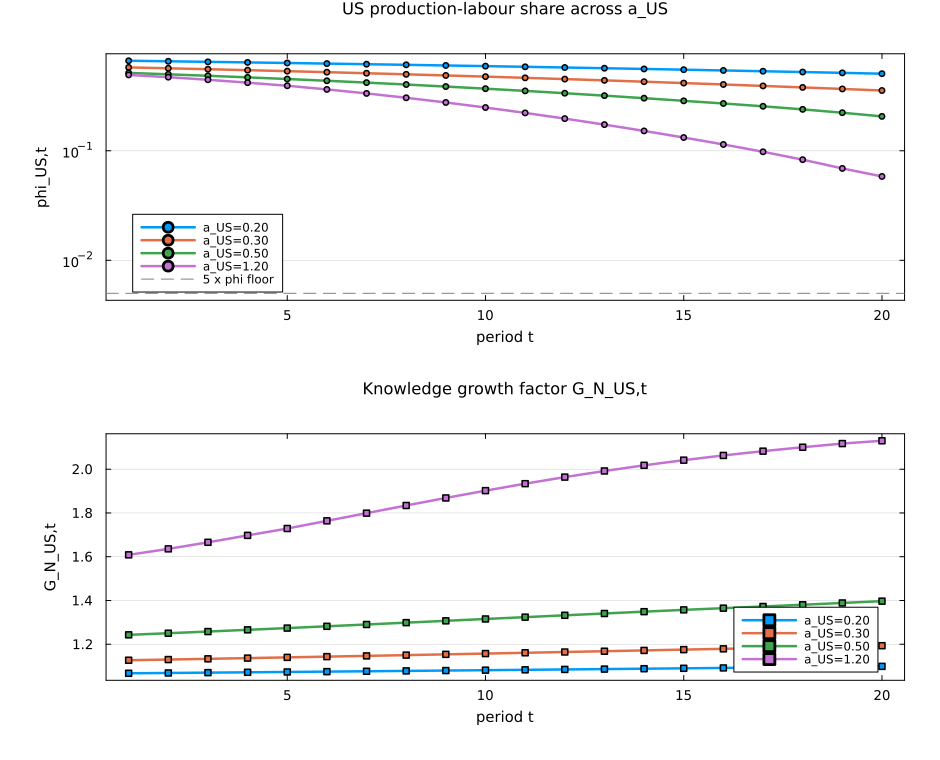

In [5]:
ok_rows = filter(r -> get(r, "status", "") == "ok", rows)

p_phi = plot(title="US production-labour share across a_US",
             xlabel="period t", ylabel="phi_US,t", yscale=:log10, legend=:bottomleft)
for r in ok_rows
    phi = r["φ_path"]
    plot!(p_phi, 1:length(phi), phi, lw=2.5, marker=:circle, ms=3,
          label=@sprintf("a_US=%.2f", r["a_US"]))
end
hline!(p_phi, [5*ProductionParams().φ_floor], ls=:dash, lc=:gray, label="5 x phi floor")

p_G = plot(title="Knowledge growth factor G_N_US,t",
           xlabel="period t", ylabel="G_N_US,t", legend=:bottomright)
for r in ok_rows
    G = r["G_path"]
    plot!(p_G, 1:length(G), G, lw=2.5, marker=:square, ms=3,
          label=@sprintf("a_US=%.2f", r["a_US"]))
end

plot(p_phi, p_G, layout=(2,1), size=(940, 760), bottom_margin=8mm)


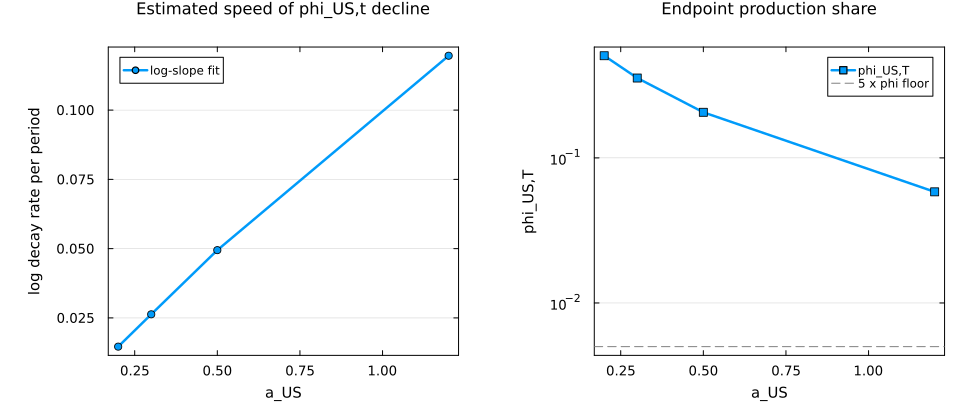

In [6]:
rate_plot = plot([r["a_US"] for r in ok_rows],
                 [r["decay_rate_per_period"] for r in ok_rows],
                 marker=:circle, lw=2.5, label="log-slope fit",
                 xlabel="a_US", ylabel="log decay rate per period",
                 title="Estimated speed of phi_US,t decline")

endpoint_plot = plot([r["a_US"] for r in ok_rows],
                     [r["φ_final"] for r in ok_rows],
                     marker=:square, lw=2.5, label="phi_US,T",
                     xlabel="a_US", ylabel="phi_US,T", yscale=:log10,
                     title="Endpoint production share")
hline!(endpoint_plot, [5*ProductionParams().φ_floor], ls=:dash, lc=:gray, label="5 x phi floor")

plot(rate_plot, endpoint_plot, layout=(1,2), size=(980, 420), bottom_margin=8mm)


## 2. Optional Extended Grid

For a denser sweep, rerun the notebook after replacing `a_US_grid` above with:

```julia
a_US_grid = [0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00, 1.20]
```

Expect the high-`a_US` rows to be provisional or slow at longer horizons. Treat `max_u_residual`, `valid_core`, and `near_floor` as binding diagnostics before interpreting late-period slopes.


## 3. Residual-Safe `T_max` Search

The practical horizon is chosen by two restrictions: the reported u-branch must pass the residual/market-clearing diagnostics, and if `φ_US` enters the near-corner band `φ_US <= 5φ_floor = 0.005`, the recommended horizon is cut to the last pre-band period. A row marked `>100 pass` means the fitted floor-band time is beyond 100 and no direct floor crossing was observed within the tested horizons.

The detail rows from the conservative run are saved in `outputs_v43/phi_decay_Tmax_detail.csv`; the final summary table is saved in `outputs_v43/phi_decay_Tmax_summary_final.csv`. The paired `a_US=a_W=0.40` row is conservatively capped at `T_max=60` because `T=80` did not return in a practical time during the boundary check.

| scenario | a_US | a_W | recommended_T_max | last_valid_T | first_invalid_or_timeout_T | floor_t_direct | floor_t_projected | corner_test | stop_reason | φ_final_last_valid | max_u_residual_last_valid |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| us_only | 0.20 | 0.20 | 100 | 100 |  |  | 172.9136 | >100 pass | reached_100 | 0.0358 | 5.118e-08 |
| us_only | 0.25 | 0.20 | 50 | 50 | 60 |  | 167.1008 | >100 pass | first_invalid_residual | 0.1464 | 4.478e-07 |
| us_only | 0.30 | 0.20 | 40 | 40 | 50 |  | 140.6582 | >100 pass | first_invalid_residual | 0.1524 | 2.093e-08 |
| us_only | 0.40 | 0.20 | 15 | 15 | 20 |  | 138.8515 | >100 pass | first_invalid_residual | 0.3382 | 4.953e-06 |
| us_only | 0.50 | 0.20 | 10 | 10 | 15 |  | 121.3513 | >100 pass | first_invalid_residual | 0.3691 | 5.567e-06 |
| us_only | 0.75 | 0.20 | 2 | 2 | 3 |  |  |  | first_invalid_residual | 0.4754 | 2.655e-08 |
| us_only | 1.00 | 0.20 | 10 | 10 | 15 |  | 77.7397 | projected 77.7 | first_invalid_residual | 0.2923 | 5.213e-09 |
| us_only | 1.20 | 0.20 | 10 | 10 | 15 |  | 57.1223 | projected 57.1 | first_invalid_residual | 0.2484 | 4.423e-09 |
| paired | 0.20 | 0.20 | 100 | 100 |  |  | 172.9136 | >100 pass | reached_100 | 0.0358 | 5.118e-08 |
| paired | 0.25 | 0.25 | 100 | 100 |  |  | 121.5891 | >100 pass | reached_100 | 0.0098 | 5.356e-07 |
| paired | 0.30 | 0.30 | 92 | 100 |  | 93 | 95.2895 | direct 93 | hit_phi_floor_band | 0.0030 | 3.646e-06 |
| paired | 0.40 | 0.40 | 60 | 60 | 80 |  | 73.9252 | projected 73.9 | timeout_unresolved | 0.0106 | 2.246e-06 |
| paired | 0.50 | 0.50 | 40 | 40 | 50 |  | 61.8997 | projected 61.9 | first_invalid_residual | 0.0238 | 4.074e-06 |
| paired | 0.75 | 0.75 | 25 | 25 | 30 |  | 43.4137 | projected 43.4 | first_invalid_residual | 0.0323 | 2.039e-06 |
| paired | 1.00 | 1.00 | 10 | 10 | 15 |  | 40.0215 | projected 40.0 | first_invalid_residual | 0.1333 | 2.603e-06 |
| paired | 1.20 | 1.20 | 10 | 10 | 15 |  | 33.1524 | projected 33.2 | first_invalid_residual | 0.1045 | 2.787e-06 |

In [ ]:
# Static copy of outputs_v43/phi_decay_Tmax_summary_final.csv for quick notebook filtering.
tmax_summary_rows = Dict{String, Any}[
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 0.20,
        "a_W" => 0.20,
        "recommended_T_max" => 100,
        "last_valid_T" => 100,
        "first_invalid_or_timeout_T" => missing,
        "floor_t_direct" => missing,
        "floor_t_projected" => 172.9136,
        "corner_test" => ">100 pass",
        "stop_reason" => "reached_100",
        "φ_final_last_valid" => 0.0358,
        "max_u_residual_last_valid" => 5.118e-08,
        "decay_rate_last_valid" => 0.0304
    ),
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 0.25,
        "a_W" => 0.20,
        "recommended_T_max" => 50,
        "last_valid_T" => 50,
        "first_invalid_or_timeout_T" => 60,
        "floor_t_direct" => missing,
        "floor_t_projected" => 167.1008,
        "corner_test" => ">100 pass",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.1464,
        "max_u_residual_last_valid" => 4.478e-07,
        "decay_rate_last_valid" => 0.0298
    ),
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 0.30,
        "a_W" => 0.20,
        "recommended_T_max" => 40,
        "last_valid_T" => 40,
        "first_invalid_or_timeout_T" => 50,
        "floor_t_direct" => missing,
        "floor_t_projected" => 140.6582,
        "corner_test" => ">100 pass",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.1524,
        "max_u_residual_last_valid" => 2.093e-08,
        "decay_rate_last_valid" => 0.0349
    ),
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 0.40,
        "a_W" => 0.20,
        "recommended_T_max" => 15,
        "last_valid_T" => 15,
        "first_invalid_or_timeout_T" => 20,
        "floor_t_direct" => missing,
        "floor_t_projected" => 138.8515,
        "corner_test" => ">100 pass",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.3382,
        "max_u_residual_last_valid" => 4.953e-06,
        "decay_rate_last_valid" => 0.0341
    ),
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 0.50,
        "a_W" => 0.20,
        "recommended_T_max" => 10,
        "last_valid_T" => 10,
        "first_invalid_or_timeout_T" => 15,
        "floor_t_direct" => missing,
        "floor_t_projected" => 121.3513,
        "corner_test" => ">100 pass",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.3691,
        "max_u_residual_last_valid" => 5.567e-06,
        "decay_rate_last_valid" => 0.0387
    ),
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 0.75,
        "a_W" => 0.20,
        "recommended_T_max" => 2,
        "last_valid_T" => 2,
        "first_invalid_or_timeout_T" => 3,
        "floor_t_direct" => missing,
        "floor_t_projected" => missing,
        "corner_test" => missing,
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.4754,
        "max_u_residual_last_valid" => 2.655e-08,
        "decay_rate_last_valid" => NaN
    ),
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 1.00,
        "a_W" => 0.20,
        "recommended_T_max" => 10,
        "last_valid_T" => 10,
        "first_invalid_or_timeout_T" => 15,
        "floor_t_direct" => missing,
        "floor_t_projected" => 77.7397,
        "corner_test" => "projected 77.7",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.2923,
        "max_u_residual_last_valid" => 5.213e-09,
        "decay_rate_last_valid" => 0.0604
    ),
    Dict{String, Any}(
        "scenario" => "us_only",
        "a_US" => 1.20,
        "a_W" => 0.20,
        "recommended_T_max" => 10,
        "last_valid_T" => 10,
        "first_invalid_or_timeout_T" => 15,
        "floor_t_direct" => missing,
        "floor_t_projected" => 57.1223,
        "corner_test" => "projected 57.1",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.2484,
        "max_u_residual_last_valid" => 4.423e-09,
        "decay_rate_last_valid" => 0.0834
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 0.20,
        "a_W" => 0.20,
        "recommended_T_max" => 100,
        "last_valid_T" => 100,
        "first_invalid_or_timeout_T" => missing,
        "floor_t_direct" => missing,
        "floor_t_projected" => 172.9136,
        "corner_test" => ">100 pass",
        "stop_reason" => "reached_100",
        "φ_final_last_valid" => 0.0358,
        "max_u_residual_last_valid" => 5.118e-08,
        "decay_rate_last_valid" => 0.0304
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 0.25,
        "a_W" => 0.25,
        "recommended_T_max" => 100,
        "last_valid_T" => 100,
        "first_invalid_or_timeout_T" => missing,
        "floor_t_direct" => missing,
        "floor_t_projected" => 121.5891,
        "corner_test" => ">100 pass",
        "stop_reason" => "reached_100",
        "φ_final_last_valid" => 0.0098,
        "max_u_residual_last_valid" => 5.356e-07,
        "decay_rate_last_valid" => 0.0433
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 0.30,
        "a_W" => 0.30,
        "recommended_T_max" => 92,
        "last_valid_T" => 100,
        "first_invalid_or_timeout_T" => missing,
        "floor_t_direct" => 93,
        "floor_t_projected" => 95.2895,
        "corner_test" => "direct 93",
        "stop_reason" => "hit_phi_floor_band",
        "φ_final_last_valid" => 0.0030,
        "max_u_residual_last_valid" => 3.646e-06,
        "decay_rate_last_valid" => 0.0553
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 0.40,
        "a_W" => 0.40,
        "recommended_T_max" => 60,
        "last_valid_T" => 60,
        "first_invalid_or_timeout_T" => 80,
        "floor_t_direct" => missing,
        "floor_t_projected" => 73.9252,
        "corner_test" => "projected 73.9",
        "stop_reason" => "timeout_unresolved",
        "φ_final_last_valid" => 0.0106,
        "max_u_residual_last_valid" => 2.246e-06,
        "decay_rate_last_valid" => 0.0677
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 0.50,
        "a_W" => 0.50,
        "recommended_T_max" => 40,
        "last_valid_T" => 40,
        "first_invalid_or_timeout_T" => 50,
        "floor_t_direct" => missing,
        "floor_t_projected" => 61.8997,
        "corner_test" => "projected 61.9",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.0238,
        "max_u_residual_last_valid" => 4.074e-06,
        "decay_rate_last_valid" => 0.0780
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 0.75,
        "a_W" => 0.75,
        "recommended_T_max" => 25,
        "last_valid_T" => 25,
        "first_invalid_or_timeout_T" => 30,
        "floor_t_direct" => missing,
        "floor_t_projected" => 43.4137,
        "corner_test" => "projected 43.4",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.0323,
        "max_u_residual_last_valid" => 2.039e-06,
        "decay_rate_last_valid" => 0.1071
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 1.00,
        "a_W" => 1.00,
        "recommended_T_max" => 10,
        "last_valid_T" => 10,
        "first_invalid_or_timeout_T" => 15,
        "floor_t_direct" => missing,
        "floor_t_projected" => 40.0215,
        "corner_test" => "projected 40.0",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.1333,
        "max_u_residual_last_valid" => 2.603e-06,
        "decay_rate_last_valid" => 0.1101
    ),
    Dict{String, Any}(
        "scenario" => "paired",
        "a_US" => 1.20,
        "a_W" => 1.20,
        "recommended_T_max" => 10,
        "last_valid_T" => 10,
        "first_invalid_or_timeout_T" => 15,
        "floor_t_direct" => missing,
        "floor_t_projected" => 33.1524,
        "corner_test" => "projected 33.2",
        "stop_reason" => "first_invalid_residual",
        "φ_final_last_valid" => 0.1045,
        "max_u_residual_last_valid" => 2.787e-06,
        "decay_rate_last_valid" => 0.1324
    ),
]
tmax_summary_cols = ["scenario", "a_US", "a_W", "recommended_T_max", "last_valid_T", "first_invalid_or_timeout_T", "floor_t_direct", "floor_t_projected", "corner_test", "stop_reason", "φ_final_last_valid", "max_u_residual_last_valid"]
markdown_table(tmax_summary_rows, tmax_summary_cols; maxrows=length(tmax_summary_rows))

## 4. Search Code

The conservative run used the same validity test as the table above:

```julia
valid_core = result.branch_converged &&
             result.max_u_residual <= 1e-5 &&
             result.max_bgp_residual <= 1e-5 &&
             result.diagnostics.psi_ok &&
             result.diagnostics.equity_weights_ok
```

Horizons were scanned upward over `[1, 2, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 80, 100]` where needed, stopping at the first failed residual test or at the first direct `φ_US <= 5φ_floor` crossing. For low-`a` rows that passed through 100, no longer horizon was tested because the intended simulations never exceed 100 periods.


## 5. Residual-Safe `Q_US/e_US` Decomposition Sweeps

This section replicates the `Q_US/e_US` demand and production decomposition sweeps from `08_v9_parameter_sweeps.ipynb`, but now on the requested upward `a_US` grid and with `T_max` adjusted case-by-case using the residual-safe horizons from Section 3.

The decomposition uses the full solved equilibrium for each row:

- Demand side: `Q_US/e_US = omega*S/e_US + omega_star*S_star/e_US`.
- Production side: `Q_US/e_US = w_H/(a_US e_US) + (1-varphi_US)H_US*w_H/e_US`, with `w_H = q_US*a_US*N_US`.

The grid is `a_US_grid = [0.20, 0.25, 0.30, 0.40, 0.50]`, run once with `a_W=0.20` and once with `a_US=a_W`.


In [ ]:
const Q_DECOMP_A_GRID = [0.20, 0.25, 0.30, 0.40, 0.50]
const SAFE_T_US_ONLY = Dict(0.20 => 100, 0.25 => 50, 0.30 => 40, 0.40 => 15, 0.50 => 10)
const SAFE_T_PAIRED  = Dict(0.20 => 100, 0.25 => 100, 0.30 => 92, 0.40 => 60, 0.50 => 40)

q_sweep_label(scenario, a) = scenario == "us_only" ? @sprintf("a_US=%.2f, a_W=0.20", a) : @sprintf("a_US=a_W=%.2f", a)

function padded_data_limits(vals; min_span=0.08, pad_frac=0.14, clamp_nonnegative=false)
    clean = [v for v in vals if isfinite(v)]
    isempty(clean) && return clamp_nonnegative ? (0.0, min_span) : (-min_span/2, min_span/2)
    lo = minimum(clean)
    hi = maximum(clean)
    clamp_nonnegative && (lo = min(lo, 0.0))
    span = max(hi - lo, min_span)
    pad = pad_frac * span
    ylo = lo - pad
    yhi = hi + pad
    clamp_nonnegative && (ylo = max(0.0, ylo))
    return (ylo, yhi)
end

const Q_DECOMP_COLORS = [:steelblue, :tomato, :seagreen, :purple, :darkorange, :darkcyan, :brown, :black]
q_decomp_color(i) = Q_DECOMP_COLORS[mod1(i, length(Q_DECOMP_COLORS))]

function q_decomposition_from_result(label::String, scenario::String, value, result)
    p = result.params
    T = length(result.u_path)
    last = late_range(T)

    e_US = [s.e_US for s in result.u_path]
    Q_e = [s.Q_US / s.e_US for s in result.u_path]
    Q_us_demand_e = [s.ω * s.S / s.e_US for s in result.u_path]
    Q_row_demand_e = [s.ω_star * s.S_star / s.e_US for s in result.u_path]

    wH_US = [s.q_US * p.a_US * s.N_US for s in result.u_path]
    Q_wage_cap_e = [(wH_US[t] / p.a_US) / e_US[t] for t in 1:T]
    Q_innovation_cap_e = [((1 - result.u_path[t].φ_US) * p.H_US * wH_US[t]) / e_US[t] for t in 1:T]

    R_A_u = [s.R_A_u for s in result.u_path]
    R_A_b = [s.R_A_b for s in result.u_path]
    valid_core = result.branch_converged && result.max_u_residual <= 1e-5 &&
                 result.max_bgp_residual <= 1e-5 &&
                 result.diagnostics.psi_ok && result.diagnostics.equity_weights_ok &&
                 minimum(R_A_u) > 0 && minimum(R_A_b) > 0
    valid_exploratory = result.max_u_residual <= 1e-4 &&
                        result.diagnostics.psi_ok && result.diagnostics.equity_weights_ok &&
                        minimum(R_A_u) > 0 && minimum(R_A_b) > 0

    return Dict{String, Any}(
        "label" => label,
        "scenario" => scenario,
        "value" => value,
        "a_US" => p.a_US,
        "a_W" => p.a_W,
        "T_max" => p.T_max,
        "status" => "ok",
        "branch_converged" => result.branch_converged,
        "max_u_residual" => result.max_u_residual,
        "max_bgp_residual" => result.max_bgp_residual,
        "psi_ok" => result.diagnostics.psi_ok,
        "equity_weights_ok" => result.diagnostics.equity_weights_ok,
        "valid_core" => valid_core,
        "valid_exploratory" => valid_exploratory,
        "Q_e_final" => Q_e[end],
        "Q_e_late_mean" => mean(Q_e[last]),
        "Q_us_demand_e_final" => Q_us_demand_e[end],
        "Q_row_demand_e_final" => Q_row_demand_e[end],
        "Q_wage_cap_e_final" => Q_wage_cap_e[end],
        "Q_innovation_cap_e_final" => Q_innovation_cap_e[end],
        "Q_demand_add_err_max" => maximum(abs.(Q_e .- Q_us_demand_e .- Q_row_demand_e)),
        "Q_prod_add_err_max" => maximum(abs.(Q_e .- Q_wage_cap_e .- Q_innovation_cap_e)),
        "Q_e_path" => Q_e,
        "Q_us_demand_e_path" => Q_us_demand_e,
        "Q_row_demand_e_path" => Q_row_demand_e,
        "Q_wage_cap_e_path" => Q_wage_cap_e,
        "Q_innovation_cap_e_path" => Q_innovation_cap_e,
        "wH_e_path" => wH_US ./ e_US,
        "φ_US_path" => [s.φ_US for s in result.u_path],
        "result" => result,
    )
end

function run_q_decomposition_case(scenario::String, a::Float64)
    T_safe = scenario == "us_only" ? SAFE_T_US_ONLY[a] : SAFE_T_PAIRED[a]
    a_W = scenario == "us_only" ? ProductionParams().a_W : a
    label = q_sweep_label(scenario, a)
    row = Dict{String, Any}(
        "label" => label,
        "scenario" => scenario,
        "value" => a,
        "a_US" => a,
        "a_W" => a_W,
        "T_max" => T_safe,
        "status" => "pending",
    )

    try
        elapsed = @elapsed begin
            result = run_production_simulation(ProductionParams(T_max=T_safe, a_US=a, a_W=a_W); verbose=false)
            merge!(row, q_decomposition_from_result(label, scenario, a, result))
        end
        row["elapsed_sec"] = elapsed
    catch err
        row["status"] = "error"
        row["error"] = sprint(showerror, err)
        row["valid_core"] = false
        row["valid_exploratory"] = false
        row["elapsed_sec"] = missing
    end
    return row
end

function run_q_decomposition_sweeps(; grid=Q_DECOMP_A_GRID)
    rows = Dict{String, Any}[]
    for scenario in ("us_only", "paired")
        for a in grid
            T_safe = scenario == "us_only" ? SAFE_T_US_ONLY[a] : SAFE_T_PAIRED[a]
            @printf("running Q/e decomposition %-8s a=%.2f, T_max=%d\n", scenario, a, T_safe)
            push!(rows, run_q_decomposition_case(scenario, a))
        end
    end
    return rows
end


In [ ]:
q_decomp_rows = run_q_decomposition_sweeps()
q_decomp_cols = ["scenario", "value", "a_US", "a_W", "T_max", "status", "valid_core", "max_u_residual", "Q_e_final", "Q_e_late_mean", "Q_us_demand_e_final", "Q_row_demand_e_final", "Q_wage_cap_e_final", "Q_innovation_cap_e_final", "Q_demand_add_err_max", "Q_prod_add_err_max", "elapsed_sec"]

function write_q_decomposition_summary(path, rows, cols)
    open(path, "w") do io
        println(io, join(cols, ","))
        for r in rows
            println(io, join([pretty(get(r, c, missing)) for c in cols], ","))
        end
    end
    return path
end

write_q_decomposition_summary("outputs_v43/phi_decay_q_decomposition_summary.csv", q_decomp_rows, q_decomp_cols)
markdown_table(q_decomp_rows, q_decomp_cols; maxrows=length(q_decomp_rows))


### Completed Q/e Sweep Summary

I ran the adjusted-horizon decomposition sweep once and saved the summary to `outputs_v43/phi_decay_q_decomposition_summary.csv`. All rows passed `valid_core` under their residual-safe `T_max`.

| scenario | value | a_US | a_W | T_max | valid_core | max_u_residual | Q_e_final | Q_e_late_mean | Q_us_demand_e_final | Q_row_demand_e_final | Q_wage_cap_e_final | Q_innovation_cap_e_final |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| us_only | 0.2000 | 0.2000 | 0.2000 | 100 | true | 5.118e-08 | 0.3066 | 0.3085 | 0.3052 | 0.0014 | 0.2570 | 0.0496 |
| us_only | 0.2500 | 0.2500 | 0.2000 | 50 | true | 4.478e-07 | 0.3007 | 0.3118 | 0.2977 | 0.0030 | 0.2478 | 0.0529 |
| us_only | 0.3000 | 0.3000 | 0.2000 | 40 | true | 2.093e-08 | 0.2765 | 0.2894 | 0.2760 | 4.927e-04 | 0.2204 | 0.0561 |
| us_only | 0.4000 | 0.4000 | 0.2000 | 15 | true | 4.953e-06 | 0.3075 | 0.3449 | 0.2986 | 0.0089 | 0.2431 | 0.0644 |
| us_only | 0.5000 | 0.5000 | 0.2000 | 10 | true | 5.567e-06 | 0.2889 | 0.3390 | 0.2798 | 0.0091 | 0.2196 | 0.0693 |
| paired | 0.2000 | 0.2000 | 0.2000 | 100 | true | 5.118e-08 | 0.3066 | 0.3085 | 0.3052 | 0.0014 | 0.2570 | 0.0496 |
| paired | 0.2500 | 0.2500 | 0.2500 | 100 | true | 5.356e-07 | 0.3029 | 0.3023 | 0.3022 | 6.403e-04 | 0.2428 | 0.0601 |
| paired | 0.3000 | 0.3000 | 0.3000 | 92 | true | 8.831e-07 | 0.3035 | 0.3017 | 0.3029 | 5.996e-04 | 0.2337 | 0.0698 |
| paired | 0.4000 | 0.4000 | 0.4000 | 60 | true | 2.246e-06 | 0.2970 | 0.2960 | 0.2966 | 3.838e-04 | 0.2128 | 0.0842 |
| paired | 0.5000 | 0.5000 | 0.5000 | 40 | true | 4.074e-06 | 0.2948 | 0.2980 | 0.2941 | 7.254e-04 | 0.1981 | 0.0967 |

In [ ]:
function q_total_path_plot(rows, param_label, title_label; show_legend=true, min_span=0.10)
    p = plot(title="US Q/e path: $(title_label)", xlabel="period t",
             ylabel=L"\mathcal{Q}_{US,t}/e_{US,t}",
             legend=show_legend ? :outerright : false,
             titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
             left_margin=12mm, right_margin=show_legend ? 4mm : 6mm,
             top_margin=8mm, bottom_margin=8mm)

    all_vals = Float64[]
    for (i, r) in enumerate(rows)
        path = r["Q_e_path"]
        tt = 1:length(path)
        append!(all_vals, path)
        plot!(p, tt, path, lw=2.2, lc=q_decomp_color(i),
              label="$(param_label)=$(pretty(r["value"]))")
    end

    ylims = padded_data_limits(all_vals; min_span=min_span, clamp_nonnegative=true)
    ylims!(p, ylims...)
    ylims[1] <= 0.0 <= ylims[2] && hline!(p, [0.0], lc=:black, lw=1, ls=:dot, label="")
    return p
end

function q_demand_components_plot(rows, title_label; min_span=0.10)
    p = plot(title="Demand components: $(title_label)", xlabel="period t",
             ylabel=L"\mathrm{component}/e_{US,t}",
             legend=:outerright, titlefontsize=11, guidefontsize=10,
             tickfontsize=9, legendfontsize=8,
             left_margin=12mm, right_margin=4mm, top_margin=8mm, bottom_margin=8mm)

    all_vals = Float64[]
    for (i, r) in enumerate(rows)
        tt = 1:length(r["Q_us_demand_e_path"])
        c = q_decomp_color(i)
        append!(all_vals, r["Q_us_demand_e_path"])
        append!(all_vals, r["Q_row_demand_e_path"])
        plot!(p, tt, r["Q_us_demand_e_path"], lw=2.0, lc=c, ls=:solid, label="")
        plot!(p, tt, r["Q_row_demand_e_path"], lw=2.0, lc=c, ls=:dash, label="")
    end

    plot!(p, [NaN], [NaN], lw=2.0, lc=:black, ls=:solid, label=L"\omega S/e")
    plot!(p, [NaN], [NaN], lw=2.0, lc=:black, ls=:dash, label=L"\omega^* S^*/e")

    ylims = padded_data_limits(all_vals; min_span=min_span, clamp_nonnegative=false)
    ylims!(p, ylims...)
    ylims[1] <= 0.0 <= ylims[2] && hline!(p, [0.0], lc=:black, lw=1, ls=:dot, label="")
    return p
end

function q_production_components_plot(rows, title_label; min_span=0.10)
    p = plot(title="Production components: $(title_label)", xlabel="period t",
             ylabel=L"\mathrm{component}/e_{US,t}",
             legend=:outerright, titlefontsize=11, guidefontsize=10,
             tickfontsize=9, legendfontsize=8,
             left_margin=12mm, right_margin=4mm, top_margin=8mm, bottom_margin=8mm)

    all_vals = Float64[]
    for (i, r) in enumerate(rows)
        tt = 1:length(r["Q_wage_cap_e_path"])
        c = q_decomp_color(i)
        append!(all_vals, r["Q_wage_cap_e_path"])
        append!(all_vals, r["Q_innovation_cap_e_path"])
        plot!(p, tt, r["Q_wage_cap_e_path"], lw=2.0, lc=c, ls=:solid, label="")
        plot!(p, tt, r["Q_innovation_cap_e_path"], lw=2.0, lc=c, ls=:dash, label="")
    end

    plot!(p, [NaN], [NaN], lw=2.0, lc=:black, ls=:solid, label=L"w_H/(a e)")
    plot!(p, [NaN], [NaN], lw=2.0, lc=:black, ls=:dash, label=L"(1-\varphi)H w_H/e")

    ylims = padded_data_limits(all_vals; min_span=min_span, clamp_nonnegative=true)
    ylims!(p, ylims...)
    ylims[1] <= 0.0 <= ylims[2] && hline!(p, [0.0], lc=:black, lw=1, ls=:dot, label="")
    return p
end

q_us_only_rows = filter(r -> get(r, "scenario", "") == "us_only" && get(r, "status", "") == "ok", q_decomp_rows)
q_paired_rows = filter(r -> get(r, "scenario", "") == "paired" && get(r, "status", "") == "ok", q_decomp_rows)

p_us_q_total = q_total_path_plot(q_us_only_rows, "a_US", "a_US, a_W=0.20"; show_legend=true, min_span=0.10)
p_us_q_demand = q_demand_components_plot(q_us_only_rows, "a_US, a_W=0.20"; min_span=0.10)
p_us_q_production = q_production_components_plot(q_us_only_rows, "a_US, a_W=0.20"; min_span=0.10)
p_pair_q_total = q_total_path_plot(q_paired_rows, "a_US=a_W", "a_US=a_W"; show_legend=true, min_span=0.10)
p_pair_q_demand = q_demand_components_plot(q_paired_rows, "a_US=a_W"; min_span=0.10)
p_pair_q_production = q_production_components_plot(q_paired_rows, "a_US=a_W"; min_span=0.10)

plot(p_us_q_total, p_us_q_demand, p_us_q_production,
     p_pair_q_total, p_pair_q_demand, p_pair_q_production,
     layout=(2,3), size=(1680, 860), margin=8mm)


## 6. Reading the Results

- Larger `a_US` raises the potential knowledge-growth factor $G_{N,US}=1+a_{US}(1-\varphi_{US})H_{US}$ and, in these solves, moves $\varphi_{US,t}$ down faster over the same 20-period window.
- The per-variety dividend yield satisfies $d_{US,t}/q_{US,t}=a_{US}(1-\vartheta_{US})\varphi_{US,t}H_{US}/\vartheta_{US}$. A higher `a_US` mechanically raises the yield at a fixed $\varphi$, but faster $\varphi$ decay can offset that later in the path.
- Rows with `valid_core=false` are still useful as stress tests, but the residual diagnostics mean they should not be treated as fully certified equilibria.


## 7. Completed Outer `vartheta_US` Sweep

The outer sweep wraps the existing residual-safe `a_US` decomposition sweep in the `vartheta_US` grid from `08_v9_parameter_sweeps.ipynb`:

- `vartheta_US_grid = [0.50, 0.60, 0.70, 0.80]`
- `a_US_grid = [0.20, 0.25, 0.30, 0.40, 0.50]`
- scenarios: `us_only` keeps `a_W=0.20`; `paired` sets `a_US=a_W`.

The sweep was executed outside the notebook kernel and saved incrementally to `outputs_v43/phi_decay_outer_vartheta_q_decomposition_summary.csv`. Each case starts from the residual-safe `T_max` cap from the previous `a_US` sweep and falls back to a lower horizon if the core residual test fails or the cap is impractically slow. The completed file has 40 rows; all 40 passed `valid_core`.

### Validity Summary

| vartheta_US | scenario | n_rows | valid_core_rows | reduced_rows | Q_e_final_min | Q_e_final_max |
| --- | --- | --- | --- | --- | --- | --- |
| 0.5000 | us_only | 5 | 5 | 0 | 0.2765 | 0.3075 |
| 0.5000 | paired | 5 | 5 | 0 | 0.2948 | 0.3066 |
| 0.6000 | us_only | 5 | 5 | 1 | 0.2687 | 0.3526 |
| 0.6000 | paired | 5 | 5 | 0 | 0.2980 | 0.3526 |
| 0.7000 | us_only | 5 | 5 | 0 | 0.2512 | 0.4375 |
| 0.7000 | paired | 5 | 5 | 0 | 0.3178 | 0.4375 |
| 0.8000 | us_only | 5 | 5 | 0 | 0.2357 | 0.5243 |
| 0.8000 | paired | 5 | 5 | 2 | 0.3073 | 0.5243 |

### Fallback Horizon Rows

| vartheta_US | scenario | a_US | a_W | T_cap | T_max | max_u_residual | Q_e_final |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.6000 | us_only | 0.2500 | 0.2000 | 50 | 40 | 2.110e-06 | 0.3317 |
| 0.8000 | paired | 0.4000 | 0.4000 | 40 | 30 | 2.434e-06 | 0.3347 |
| 0.8000 | paired | 0.5000 | 0.5000 | 40 | 30 | 2.914e-06 | 0.3073 |

### Compact Full Results

| vartheta_US | scenario | a_US | a_W | T_cap | T_max | valid_core | reduced_from_cap | max_u_residual | Q_e_final | Q_e_late_mean | Q_us_demand_e_final | Q_row_demand_e_final | Q_wage_cap_e_final | Q_innovation_cap_e_final |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0.5000 | us_only | 0.2000 | 0.2000 | 100 | 100 | true | false | 5.118e-08 | 0.3066 | 0.3116 | 0.3052 | 0.0014 | 0.2570 | 0.0496 |
| 0.5000 | us_only | 0.2500 | 0.2000 | 50 | 50 | true | false | 4.478e-07 | 0.3007 | 0.3271 | 0.2977 | 0.0030 | 0.2478 | 0.0529 |
| 0.5000 | us_only | 0.3000 | 0.2000 | 40 | 40 | true | false | 2.093e-08 | 0.2765 | 0.3095 | 0.2760 | 4.927e-04 | 0.2204 | 0.0561 |
| 0.5000 | us_only | 0.4000 | 0.2000 | 15 | 15 | true | false | 4.953e-06 | 0.3075 | 0.3691 | 0.2986 | 0.0089 | 0.2431 | 0.0644 |
| 0.5000 | us_only | 0.5000 | 0.2000 | 10 | 10 | true | false | 5.567e-06 | 0.2889 | 0.3390 | 0.2798 | 0.0091 | 0.2196 | 0.0693 |
| 0.5000 | paired | 0.2000 | 0.2000 | 100 | 100 | true | false | 5.118e-08 | 0.3066 | 0.3116 | 0.3052 | 0.0014 | 0.2570 | 0.0496 |
| 0.5000 | paired | 0.2500 | 0.2500 | 100 | 100 | true | false | 5.356e-07 | 0.3029 | 0.3026 | 0.3022 | 6.403e-04 | 0.2428 | 0.0601 |
| 0.5000 | paired | 0.3000 | 0.3000 | 92 | 92 | true | false | 8.831e-07 | 0.3035 | 0.3008 | 0.3029 | 5.996e-04 | 0.2337 | 0.0698 |
| 0.5000 | paired | 0.4000 | 0.4000 | 60 | 60 | true | false | 2.246e-06 | 0.2970 | 0.2977 | 0.2966 | 3.838e-04 | 0.2128 | 0.0842 |
| 0.5000 | paired | 0.5000 | 0.5000 | 40 | 40 | true | false | 4.074e-06 | 0.2948 | 0.3083 | 0.2941 | 7.254e-04 | 0.1981 | 0.0967 |
| 0.6000 | us_only | 0.2000 | 0.2000 | 100 | 100 | true | false | 1.038e-08 | 0.3526 | 0.3515 | 0.3481 | 0.0045 | 0.2962 | 0.0564 |
| 0.6000 | us_only | 0.2500 | 0.2000 | 50 | 40 | true | true | 2.110e-06 | 0.3317 | 0.3622 | 0.3230 | 0.0087 | 0.2813 | 0.0505 |
| 0.6000 | us_only | 0.3000 | 0.2000 | 40 | 40 | true | false | 6.172e-06 | 0.2762 | 0.3064 | 0.2744 | 0.0018 | 0.2226 | 0.0535 |
| 0.6000 | us_only | 0.4000 | 0.2000 | 15 | 15 | true | false | 7.916e-07 | 0.2932 | 0.3425 | 0.2837 | 0.0095 | 0.2373 | 0.0559 |
| 0.6000 | us_only | 0.5000 | 0.2000 | 10 | 10 | true | false | 9.501e-06 | 0.2687 | 0.3080 | 0.2591 | 0.0095 | 0.2102 | 0.0584 |
| 0.6000 | paired | 0.2000 | 0.2000 | 100 | 100 | true | false | 1.038e-08 | 0.3526 | 0.3515 | 0.3481 | 0.0045 | 0.2962 | 0.0564 |
| 0.6000 | paired | 0.2500 | 0.2500 | 60 | 60 | true | false | 4.842e-07 | 0.3366 | 0.3483 | 0.3306 | 0.0060 | 0.2751 | 0.0615 |
| 0.6000 | paired | 0.3000 | 0.3000 | 60 | 60 | true | false | 3.264e-08 | 0.3237 | 0.3269 | 0.3198 | 0.0038 | 0.2519 | 0.0718 |
| 0.6000 | paired | 0.4000 | 0.4000 | 40 | 40 | true | false | 4.374e-07 | 0.3094 | 0.3275 | 0.3057 | 0.0037 | 0.2252 | 0.0842 |
| 0.6000 | paired | 0.5000 | 0.5000 | 40 | 40 | true | false | 3.366e-06 | 0.2980 | 0.3072 | 0.2965 | 0.0015 | 0.2006 | 0.0974 |
| 0.7000 | us_only | 0.2000 | 0.2000 | 100 | 100 | true | false | 7.441e-08 | 0.4375 | 0.4277 | 0.5125 | -0.0750 | 0.3684 | 0.0690 |
| 0.7000 | us_only | 0.2500 | 0.2000 | 50 | 50 | true | false | 2.158e-06 | 0.3268 | 0.3443 | 0.3190 | 0.0078 | 0.2752 | 0.0516 |
| 0.7000 | us_only | 0.3000 | 0.2000 | 40 | 40 | true | false | 1.875e-06 | 0.2795 | 0.3077 | 0.2753 | 0.0042 | 0.2286 | 0.0509 |
| 0.7000 | us_only | 0.4000 | 0.2000 | 15 | 15 | true | false | 8.682e-07 | 0.2820 | 0.3204 | 0.2715 | 0.0105 | 0.2343 | 0.0477 |
| 0.7000 | us_only | 0.5000 | 0.2000 | 10 | 10 | true | false | 7.292e-07 | 0.2512 | 0.2817 | 0.2410 | 0.0102 | 0.2032 | 0.0480 |
| 0.7000 | paired | 0.2000 | 0.2000 | 100 | 100 | true | false | 7.441e-08 | 0.4375 | 0.4277 | 0.5125 | -0.0750 | 0.3684 | 0.0690 |
| 0.7000 | paired | 0.2500 | 0.2500 | 60 | 60 | true | false | 5.550e-07 | 0.3677 | 0.3722 | 0.3628 | 0.0049 | 0.3022 | 0.0654 |
| 0.7000 | paired | 0.3000 | 0.3000 | 60 | 60 | true | false | 5.194e-07 | 0.3448 | 0.3454 | 0.3395 | 0.0052 | 0.2691 | 0.0757 |
| 0.7000 | paired | 0.4000 | 0.4000 | 40 | 40 | true | false | 3.393e-06 | 0.3279 | 0.3320 | 0.3221 | 0.0058 | 0.2396 | 0.0883 |
| 0.7000 | paired | 0.5000 | 0.5000 | 40 | 40 | true | false | 3.420e-08 | 0.3178 | 0.3108 | 0.3140 | 0.0038 | 0.2143 | 0.1035 |
| 0.8000 | us_only | 0.2000 | 0.2000 | 100 | 100 | true | false | 1.631e-09 | 0.5243 | 0.5192 | 0.4909 | 0.0334 | 0.4434 | 0.0809 |
| 0.8000 | us_only | 0.2500 | 0.2000 | 50 | 50 | true | false | 3.461e-07 | 0.3587 | 0.3663 | 0.3594 | -6.633e-04 | 0.3068 | 0.0519 |
| 0.8000 | us_only | 0.3000 | 0.2000 | 40 | 40 | true | false | 1.083e-06 | 0.2957 | 0.3153 | 0.2879 | 0.0078 | 0.2463 | 0.0495 |
| 0.8000 | us_only | 0.4000 | 0.2000 | 15 | 15 | true | false | 6.428e-07 | 0.2734 | 0.3014 | 0.2633 | 0.0100 | 0.2342 | 0.0391 |
| 0.8000 | us_only | 0.5000 | 0.2000 | 10 | 10 | true | false | 6.734e-07 | 0.2357 | 0.2583 | 0.2345 | 0.0012 | 0.1981 | 0.0376 |
| 0.8000 | paired | 0.2000 | 0.2000 | 100 | 100 | true | false | 1.631e-09 | 0.5243 | 0.5192 | 0.4909 | 0.0334 | 0.4434 | 0.0809 |
| 0.8000 | paired | 0.2500 | 0.2500 | 60 | 60 | true | false | 1.968e-07 | 0.4136 | 0.4080 | 0.4343 | -0.0208 | 0.3425 | 0.0711 |
| 0.8000 | paired | 0.3000 | 0.3000 | 60 | 60 | true | false | 3.051e-07 | 0.3805 | 0.3737 | 0.3881 | -0.0076 | 0.2980 | 0.0825 |
| 0.8000 | paired | 0.4000 | 0.4000 | 40 | 30 | true | true | 2.434e-06 | 0.3347 | 0.3552 | 0.3273 | 0.0073 | 0.2532 | 0.0815 |
| 0.8000 | paired | 0.5000 | 0.5000 | 40 | 30 | true | true | 2.914e-06 | 0.3073 | 0.3271 | 0.3011 | 0.0062 | 0.2124 | 0.0949 |


## 8. Outer `vartheta_US` Path Plots

These figures repeat the benchmark six-panel `Q_US/e_US` path and decomposition plots for each outer `vartheta_US` value. Within each figure, the top row is the `us_only` inner sweep over `a_US` with `a_W=0.20`, and the bottom row is the paired sweep with `a_US=a_W`. All paths use the residual-safe `T_max` accepted in the completed outer sweep above.

The long path data behind the figures is saved at `outputs_v43/phi_decay_outer_vartheta_q_decomposition_paths.csv`.

### `vartheta_US = 0.50`

![Outer vartheta 0.50 Q/e decomposition](outputs_v43/phi_decay_outer_vartheta_q_decomposition_paths_vartheta_0p50.png)

### `vartheta_US = 0.60`

![Outer vartheta 0.60 Q/e decomposition](outputs_v43/phi_decay_outer_vartheta_q_decomposition_paths_vartheta_0p60.png)

### `vartheta_US = 0.70`

![Outer vartheta 0.70 Q/e decomposition](outputs_v43/phi_decay_outer_vartheta_q_decomposition_paths_vartheta_0p70.png)

### `vartheta_US = 0.80`

![Outer vartheta 0.80 Q/e decomposition](outputs_v43/phi_decay_outer_vartheta_q_decomposition_paths_vartheta_0p80.png)


## 9. Outer Paired `vartheta_US = vartheta_W` Path Plots

This outer sweep sets `vartheta_US = vartheta_W` on `[0.50, 0.60, 0.70, 0.80]`. For each paired-`vartheta` value, the same six-panel `Q_US/e_US` path/decomposition plot is repeated: top row is the `us_only` inner sweep over `a_US` with `a_W=0.20`, and bottom row is the paired `a_US=a_W` sweep.

The residual-safe procedure is applied before plotting. Each calibration first tries its current `T_cap`; if that is not residual-safe, the script searches downward over candidate horizons and plots only the accepted `valid_core=true` `T_max`. The completed sweep has 40/40 `status=ok` rows and 40/40 `valid_core=true` rows.

Summary data: `outputs_v43/phi_decay_outer_paired_vartheta_q_decomposition_summary.csv`  
Path data: `outputs_v43/phi_decay_outer_paired_vartheta_q_decomposition_paths.csv`

Fallback rows where the plotted residual-safe `T_max` is below the initial `T_cap`:

|vartheta_US|vartheta_W|scenario|a_US|a_W|T_cap|T_max|valid_core|
|---|---|---|---|---|---|---|---|
|0.6000|0.6000|us_only|0.5000|0.2000|10|7|true|
|0.7000|0.7000|us_only|0.5000|0.2000|10|7|true|
|0.8000|0.8000|us_only|0.2500|0.2000|50|40|true|
|0.8000|0.8000|us_only|0.3000|0.2000|40|30|true|

### `vartheta_US = vartheta_W = 0.50`

![Outer paired vartheta 0.50 Q/e decomposition](outputs_v43/phi_decay_outer_paired_vartheta_q_decomposition_paths_vartheta_0p50.png)

### `vartheta_US = vartheta_W = 0.60`

![Outer paired vartheta 0.60 Q/e decomposition](outputs_v43/phi_decay_outer_paired_vartheta_q_decomposition_paths_vartheta_0p60.png)

### `vartheta_US = vartheta_W = 0.70`

![Outer paired vartheta 0.70 Q/e decomposition](outputs_v43/phi_decay_outer_paired_vartheta_q_decomposition_paths_vartheta_0p70.png)

### `vartheta_US = vartheta_W = 0.80`

![Outer paired vartheta 0.80 Q/e decomposition](outputs_v43/phi_decay_outer_paired_vartheta_q_decomposition_paths_vartheta_0p80.png)
